# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 37     |  |
| :-------------|:-------------|
| Yu He Zhang| 6455417 |
| Alek Janssen| 6570224 |
| Elisabeth Mijnders| 6580971 |
| Planning Groep: 37     |Tijdstip / Tijdspanne  |
| Apperatuur in orde | 11:10 |
| Bekende condensator meten | 11:40 |
| Eigen plaat condensator af| 12:30 |
| Pauze | 12:30 - 13:30|
| Opdrachte synthese | 14:00 |
| Ontwerpgrafiek van LTSpice | 14:30 |
| Sensor af | 15:30 |
| kalibratie meting | 15:45 |
| Grafiek | 16:30 |
| Conclusie schrijven / alles af | 17:00 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schetsopdracht1.jpg" alt="schets student 1" width="400"/>
<img src="berekeningc.jpg" alt="schets student 1" width="400"/>
<img src="berekeningv.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

e0 = 8.854e-12  # permittiviteit van vacuum (F/m)

def vlakkeplaat(A, d):
    C = e0 * (A / d) *10**12
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

l= 0.149 #m
b= 0.1 #m
A = l*b

d= 0.001 #m

C = [vlakkeplaat(A,d),vlakkeplaat(A,0.004),vlakkeplaat(A,0.002)]


print(f"Berekende capaciteit plaatcondensator groep 37 is {C[0]:.1f} pF")

Berekende capaciteit plaatcondensator groep 37 is 131.9 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](opstelling.jpg)
![scope meting 2](osciloscoop.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 37| 131.9 pF | 0.66 V | 1.48 V | 147.22 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](3schetsen.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die massa meet door middel van afstand.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](schets.jpg)

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


    Als je m*g = k*u en C = e0 *A/d samenvoegt krijg je, C=e0*A/(m*g/k) in dit geval is de evenwichtsstand bij d0=0.00035 m 
    dit geeft: C=e0*A/(d0-(m*g/k))
      


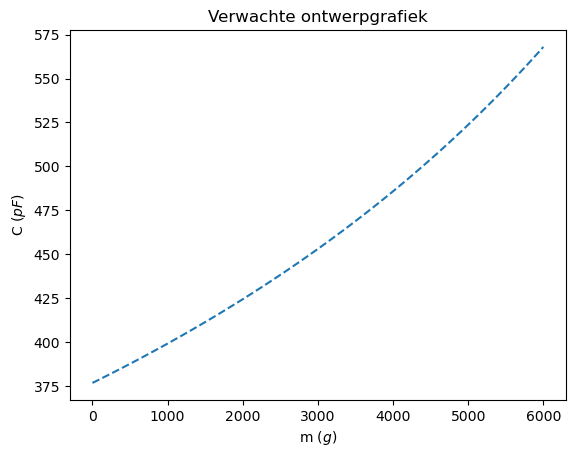

In [4]:
m0 = np.linspace(0,6000,100)


print(
    '''
    Als je m*g = k*u en C = e0 *A/d samenvoegt krijg je, C=e0*A/(m*g/k) in dit geval is de evenwichtsstand bij d0=0.00035 m 
    dit geeft: C=e0*A/(d0-(m*g/k))
      ''')

def functie(m):
    return e0*A/(d0-(m*(10**-3*g/k)))*10**12 #want gemeten waardes zijn in pF

l= 0.149 #m
b= 0.1 #m
A = l*b

g=9.81
d0=0.35*10**-3 #m
e0 = 8.854e-12

#schatting k, hierbij gaan we ervanuit dat k constant is
cx = np.array([47.5,63,78.5])
mx = np.array([45,260.25,462.5])

def functie2(m,c):
    return m*10**-3*g*c*10**-12/(c*10**-12*d0-e0*A)  #schatting in N/m

k=functie2(mx,cx)
k=np.mean(k)

k=5*10**5

yfit0 = functie(m0)

plt.title("Verwachte ontwerpgrafiek")
plt.plot(m0,yfit0,"--")
plt.ylabel("C $(pF)$")
plt.xlabel("m $(g)$")
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 47.5 | 238.8 |
| gemiddelde capaciteit| 63 | 316.65 |
| maximale capaciteit| 78.5 | 385.5 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](opstelling1.jpg)
![meting 1](opstellingmeting1.jpg)
Meting 1


![meting 2](opstelling2.jpg)
![meting 2](opstellingmeting2.jpg)
Meting 2

## Opdracht 7: Plot de kalibratiegrafiek.

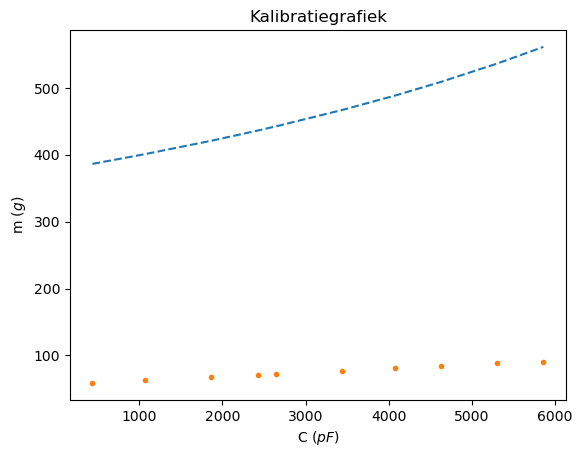

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

m= np.array([437.9,1072.3,1868.1,2423.9,2644.6,3440.4,4074.8,4630.6,5304.1,5859.9])
c= np.array([59,62.8,67.1,70.7,72.5,76.2,80.9,84.2,88.3,90.6])
merr=np.array([0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2])
cerr=np.array([0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2])

yfit = functie(m)

plt.title("Kalibratiegrafiek")
plt.xlabel("C $(pF)$")
plt.ylabel("m $(g)$")
plt.plot(m,yfit,"--",label="Kalibratiegrafiek")
plt.errorbar(m,c,yerr=cerr,xerr=merr,fmt=".")
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* De spons bedekt niet de hele plaat, dus een grotere spons die de hele plaat bedekt
* De condensator plaat groter maken, dus de capaciteit vergroten waardoor er nauwkeuriger gemeten kan worden

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](opstellingaanpassing.jpg)

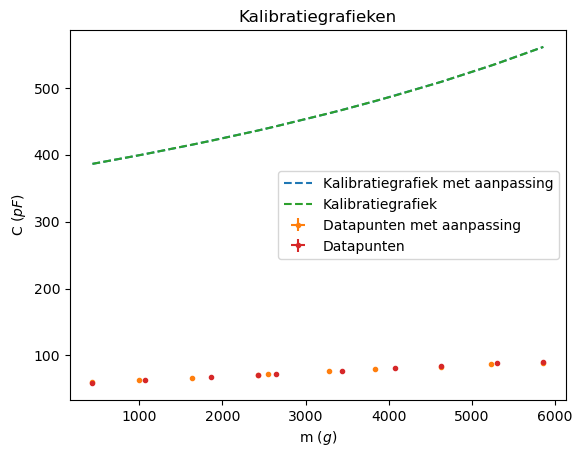

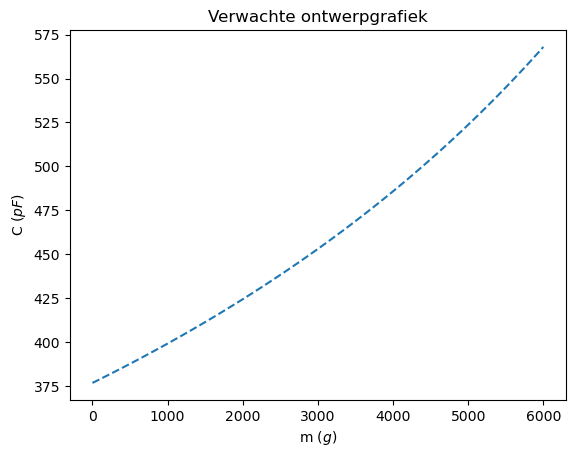

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

m= np.array([437.9,1072.3,1868.1,2423.9,2644.6,3440.4,4074.8,4630.6,5304.1,5859.9])
c= np.array([59,62.8,67.1,70.7,72.5,76.2,80.9,84.2,88.3,90.6])
m1 = np.array([437.9,995.7,1630.1,2425.9,2544.6,3279.0,3834.8,4630.6,5225.5,5859.6])
c1 = np.array([60.9,63.2,66.0,70.4,72.7,76.2,79.1,82.1,86.6,89.3])
merr=np.array([0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2])
cerr=np.array([0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2])

yfit1 = functie(m1)
yfit = functie(m)

plt.title("Kalibratiegrafieken")
plt.plot(m1,yfit1,"--",label="Kalibratiegrafiek met aanpassing")
plt.errorbar(m1,c1,yerr=cerr,xerr=merr,fmt=".",label="Datapunten met aanpassing")
plt.plot(m,yfit,"--",label="Kalibratiegrafiek")
plt.errorbar(m,c,yerr=cerr,xerr=merr,fmt=".",label="Datapunten")
plt.legend()
plt.ylabel("C $(pF)$")
plt.xlabel("m $(g)$")
plt.show()

yfit0 = functie(m0)

plt.title("Verwachte ontwerpgrafiek")
plt.plot(m0,yfit0,"--")
plt.ylabel("C $(pF)$")
plt.xlabel("m $(g)$")
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.


De sensor is geschikt om veranderingen in massa te meten in de range van 0 tot 6 kg. De verbetering uit de iteratie stap heeft geen verbetering opgeleverd. De reden hiervoor is dat de spons nu stugger is waardoor het langer duurt totdat de de condensator waarde stabiliseert. 

Er zit geen groot verschil tussen de kalibratiegrafiek en de ontwerpgrafiek, maar de kalibratiegrafiek is heel erg verschillend van de meetwaarden. Dit kan komen doordat er bij het model gebruik gemaakt wordt van e0 de permittiviteit van vacuüm, terwijl er bij de meting een spons tussen de platen zat en geen vaccuum, en een spons een andere diëlektrische constante heeft. Ook is er een schatting gemaakt voor k, de veerconstante waarbij ervanuit gegaan is dat deze constant is. Maar de veerconstante van een spons is niet constant, terwijl dit wel een aanname was. Dit kan verklaren waarom de gemeten waardes zoveel verschillen van de berekende waardes volgens het model. 

De vlakkeplaatformule klopt dus niet genoeg voor onze sensor omdat de verwachting heel erg anders is dan de uiteindelijke meetwaardes.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](3schetsen.jpg)

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](opstellingaanpassing.jpg)



    Als je m*g = k*u en C = e0 *A/d samenvoegt krijg je, C=e0*A/(m*g/k) in dit geval is de evenwichtsstand bij d0=0.00035 m 
    dit geeft: C=e0*A/(d0-(m*g/k))
      


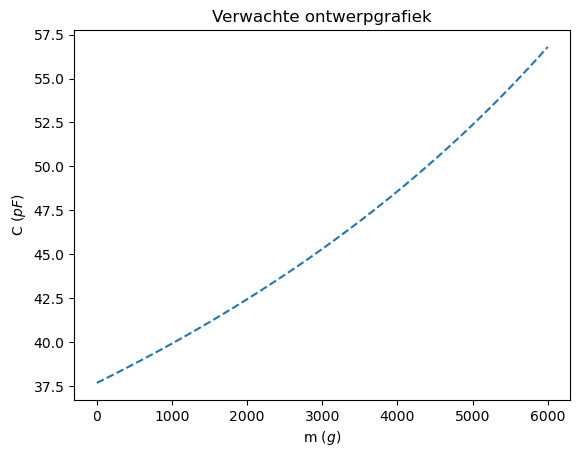

In [7]:
m0 = np.linspace(0,6000,100)


print(
    '''
    Als je m*g = k*u en C = e0 *A/d samenvoegt krijg je, C=e0*A/(m*g/k) in dit geval is de evenwichtsstand bij d0=0.00035 m 
    dit geeft: C=e0*A/(d0-(m*g/k))
      ''')

def functie(m):
    return e0*A/(d0-(m*(10**-3*g/k)))*10**12 #want gemeten waardes zijn in pF

l= 0.149 #m
b= 0.1 #m
A = l*b

g=9.81
d0=3.5*10**-3 #m
e0 = 8.854e-12

#schatting k, hierbij gaan we ervanuit dat k constant is
k=5*10**4

yfit0 = functie(m0)

plt.title("Verwachte ontwerpgrafiek")
plt.plot(m0,yfit0,"--")
plt.ylabel("C $(pF)$")
plt.xlabel("m $(g)$")
plt.show()

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](opstellingaanpassing.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 37| 131.9 pF | 0.66 V | 1.48 V | 147.22 pF |

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="schetsopdracht1.jpg" alt="schets student 1" width="400"/>
<img src="berekeningc.jpg" alt="schets student 1" width="400"/>
<img src="berekeningv.jpg" alt="schets student 1" width="400"/>

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 47.5 | 238.8 |
| gemiddelde capaciteit| 63 | 316.65 |
| maximale capaciteit| 78.5 | 385.5 |


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.


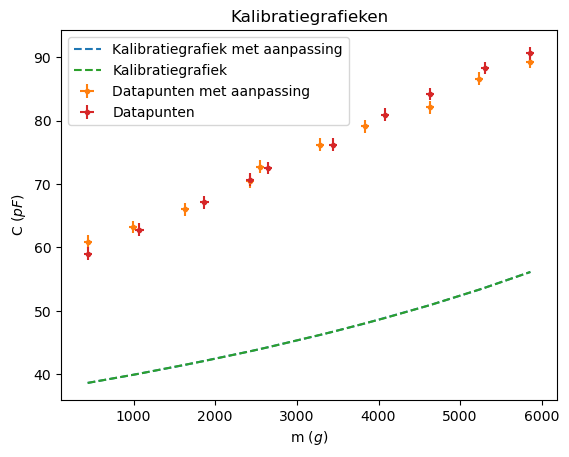

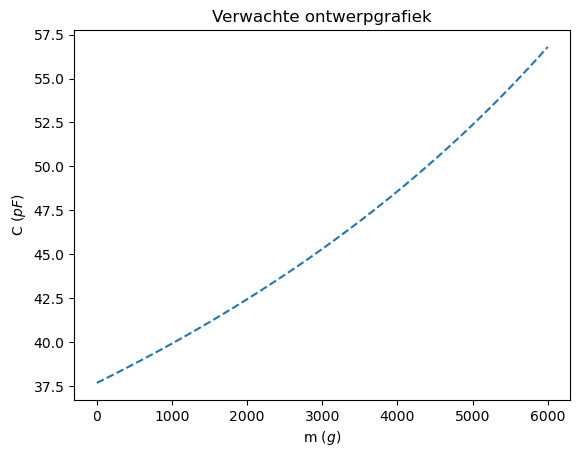

In [8]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

m= np.array([437.9,1072.3,1868.1,2423.9,2644.6,3440.4,4074.8,4630.6,5304.1,5859.9])
c= np.array([59,62.8,67.1,70.7,72.5,76.2,80.9,84.2,88.3,90.6])
m1 = np.array([437.9,995.7,1630.1,2425.9,2544.6,3279.0,3834.8,4630.6,5225.5,5859.6])
c1 = np.array([60.9,63.2,66.0,70.4,72.7,76.2,79.1,82.1,86.6,89.3])
merr=np.array([50,50,50,50,50,50,50,50,50,50])
cerr=np.array([1,1,1,1,1,1,1,1,1,1])

yfit1 = functie(m1)
yfit = functie(m)

plt.title("Kalibratiegrafieken")
plt.plot(m1,yfit1,"--",label="Kalibratiegrafiek met aanpassing")
plt.errorbar(m1,c1,yerr=cerr,xerr=merr,fmt=".",label="Datapunten met aanpassing")
plt.plot(m,yfit,"--",label="Kalibratiegrafiek")
plt.errorbar(m,c,yerr=cerr,xerr=merr,fmt=".",label="Datapunten")
plt.legend()
plt.ylabel("C $(pF)$")
plt.xlabel("m $(g)$")
plt.show()

yfit0 = functie(m0)

plt.title("Verwachte ontwerpgrafiek")
plt.plot(m0,yfit0,"--")
plt.ylabel("C $(pF)$")
plt.xlabel("m $(g)$")
plt.show()


De sensor is geschikt om veranderingen in massa te meten in de range van 0 tot 6 kg. De verbetering uit de iteratie stap heeft geen verbetering opgeleverd. De reden hiervoor is dat de spons nu stugger is waardoor het langer duurt totdat de de condensator waarde stabiliseert. 

Er zit geen groot verschil tussen de kalibratiegrafiek en de ontwerpgrafiek, maar de kalibratiegrafiek is heel erg verschillend van de meetwaarden. Dit kan komen doordat er bij het model gebruik gemaakt wordt van e0 de permittiviteit van vacuüm, terwijl er bij de meting een spons tussen de platen zat en geen vaccuum, en een spons een andere diëlektrische constante heeft. Ook is er een schatting gemaakt voor k, de veerconstante waarbij ervanuit gegaan is dat deze constant is. Maar de veerconstante van een spons is niet constant, terwijl dit wel een aanname was. Dit kan verklaren waarom de gemeten waardes zoveel verschillen van de berekende waardes volgens het model. 

De vlakkeplaatformule klopt dus niet genoeg voor onze sensor omdat de verwachting heel erg anders is dan de uiteindelijke meetwaardes.